# Traffic Flow Prediction: Machine Learning Models
**Phase 2: Model Development & Evaluation**

**Project Goal:**
This notebook builds the prediction engine for our Traffic-Based Route Guidance System (TBRGS). We are using historical traffic data from Boroondara (October 2006) to teach the computer how to forecast upcoming traffic congestion.

**What we are doing:**
We are building and comparing three different neural networks to see which one predicts traffic best:
1. **LSTM (Long Short-Term Memory):** A model specifically designed to remember patterns over long sequences of time.
2. **GRU (Gated Recurrent Unit):** Similar to LSTM, but mathematically simpler and often faster to train.
3. **FNN (Feedforward Neural Network):** A basic model that does not understand time sequences natively. We use this as a baseline to prove why the more advanced LSTM and GRU models are necessary.

We will evaluate them based on how closely their predictions match the actual number of cars on the road.

In [1]:
# Standard Data Libraries
import os
import sys
import numpy as np
import pandas as pd
import joblib
import re
import warnings
from pathlib import Path

# Machine Learning Libraries
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Flatten

# Visualization
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Path resolution for all environments & Privacy filter
# ---------------------------------------------------------

# Suppress warnings to prevent leaking private absolute paths in error/warning logs
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore')

# For Google Colab ONLY: Mount Drive
if 'google.colab' in sys.modules:
    from google.colab import drive # type: ignore
    drive.mount('/content/drive', force_remount=True)
    print("\nGoogle Colab Detected. Executing fast structural search...")

def get_project_root(marker_path="data/processed/Scats_Data_Cleaned_GapSafe.csv"):
    """
    Locates the project root dynamically by hunting for a specific structural marker.
    Uses native OS traversal for local environments and fast Linux search in Colab.
    """
    # Check local environment first
    current = Path.cwd().resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker_path).exists():
            return parent

    # Colab-specific: Linux-based Search in Drive for the specific file
    if 'google.colab' in sys.modules:
        # Use -path to find the exact structural match
        # Limit maxdepth to 9 to keep it lightning fast
        # -print -quit stops the search the exact millisecond it finds the first match
        cmd = f'find /content/drive -maxdepth 9 -ipath "*{marker_path}" -print -quit'
        found_marker = os.popen(cmd).read().strip()

        if found_marker:
            # Dynamically remove the marker suffix to find the root
            # This mathematically adapts to any shared drive structure or custom naming
            root_str = re.sub(re.escape(marker_path), "", found_marker, flags=re.IGNORECASE).rstrip("/")
            return Path(root_str)

    return None

# 1. FIND & ASSIGN PROJECT ROOT
root = get_project_root()

if root:
    BASE_PATH = str(root)

    # Set working directory of the notebook strictly to the root folder
    os.chdir(BASE_PATH)

    if BASE_PATH not in sys.path:
        sys.path.insert(0, BASE_PATH)

    # Safely get parent name for privacy logging (Sanitizing the output)
    try:
        parent_name = root.parent.name if root.parent.name else "Root"
        display_name = f".../{parent_name}/{root.name}"
    except Exception:
        display_name = f".../{root.name}"

    print(f"Project root successfully located and verified at: {display_name}")
else:
    print("Error: Could not find project structure. Check if 'data/processed/Scats_Data_Cleaned_GapSafe.csv' exists.")
    BASE_PATH = None

# 2. ASSIGN RELATIVE DIRECTORIES
if BASE_PATH:
    DATA_PATH = os.path.join(BASE_PATH, 'data', 'processed', 'Scats_Data_Cleaned_GapSafe.csv')
    MODEL_DIR = os.path.join(BASE_PATH, 'models', 'saved_models')
    SCALER_DIR = os.path.join(BASE_PATH, 'models', 'scalers')

    # Strictly enforce the folder architecture before proceeding
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(SCALER_DIR, exist_ok=True)

Project root successfully located and verified at: .../COS30019/Assignment2


## 1 - Preparing the Data (Scaling)

Machine learning models process numbers using matrix math. If we feed the model raw traffic counts (like 1,500 cars), the large numbers can cause calculation errors during training.

To fix this, we use a tool called a `MinMaxScaler`. It takes all our traffic numbers and proportionally shrinks them down so they fit exactly between 0.0 and 1.0. We save this exact scaling rule to a file so we can use it later when the GUI is running live.

In [2]:
# Load the cleaned dataset
df = pd.read_csv(DATA_PATH)

# Extract the traffic counts
flow_data = df[['Flow']].values.astype('float32')

# Compress the numbers to a range between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_flow = scaler.fit_transform(flow_data)

# Save the scaler tool for the live application
scaler_path = os.path.join(SCALER_DIR, 'flow_scaler.save')
joblib.dump(scaler, scaler_path)

print(f"Data scaling complete. Total recorded intervals: {len(scaled_flow)}")
print(f"Scaler saved to: .../{os.path.relpath(scaler_path, BASE_PATH)}")

Data scaling complete. Total recorded intervals: 118944
Scaler saved to: .../models\scalers\flow_scaler.save


## 2 - Formatting Time Sequences and Handling Missing Data

To predict the future, the models need to look at the recent past. We group our data into "sliding windows." In this setup, we look at the traffic from the past 3 intervals (45 minutes) to predict the traffic for the next 1 interval (15 minutes).

**The Missing Data Filter:**
In our raw dataset, several days of data were missing due to broken sensors. We previously marked these gaps as `NaN` (Not a Number). The code below checks every 45-minute window. If a window contains a `NaN`, it throws that sequence away. This ensures our model only learns from continuous, real-world time sequences, rather than learning impossible "jumps" in time.

In [3]:
def create_strict_sliding_windows(data, window_size):
    """
    Groups data into input sequences (X) and target predictions (y).
    Automatically discards any sequence with missing data to prevent errors.
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        window = data[i : i + window_size]
        target = data[i + window_size]

        # If the data is broken/missing, skip it completely
        if np.isnan(window).any() or np.isnan(target):
            continue

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

# Use 3 time steps (45 minutes of history)
TIME_STEPS = 3
X, y = create_strict_sliding_windows(scaled_flow, TIME_STEPS)

# Split data: 80% for training the model, 20% for testing it later
split_index = int(len(X) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Total Training Examples: {len(X_train)}")
print(f"Total Testing Examples: {len(X_test)}")

Total Training Examples: 92976
Total Testing Examples: 23244


## 3 - Building the Models

We use the Keras library to build the structural layers of our three models.

To ensure our models learn general traffic patterns instead of just memorizing the October 2006 dataset, we add a `Dropout` layer. This randomly turns off 20% of the model's connections during training, forcing it to find more robust patterns.

In [4]:
input_shape = (X_train.shape[1], X_train.shape[2])

def build_lstm():
    model = Sequential(name="LSTM_Model")
    model.add(LSTM(64, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru():
    model = Sequential(name="GRU_Model")
    model.add(GRU(64, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

def build_fnn():
    # Baseline basic model for comparison
    model = Sequential(name="Feedforward_Baseline")
    model.add(Flatten(input_shape=input_shape))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

models = {
    "LSTM": build_lstm(),
    "GRU": build_gru(),
    "FNN": build_fnn()
}

print("Models built successfully.")

Models built successfully.


## 4 - Training and Checking for Overfitting

During training, the models review the data 20 times (epochs) to adjust their math.

We hold back a small portion of the training data as a "Validation Split." The graphs below show the error rate. If the blue line (Training Error) goes down, but the orange line (Validation Error) starts going up, it means the model is "overfitting" (memorizing data) and failing to predict new information. A successful model will see both lines drop and stabilize together.

Starting the training process...

Training LSTM model...
Training GRU model...
Training FNN model...

All models trained and saved. Generating performance graphs...


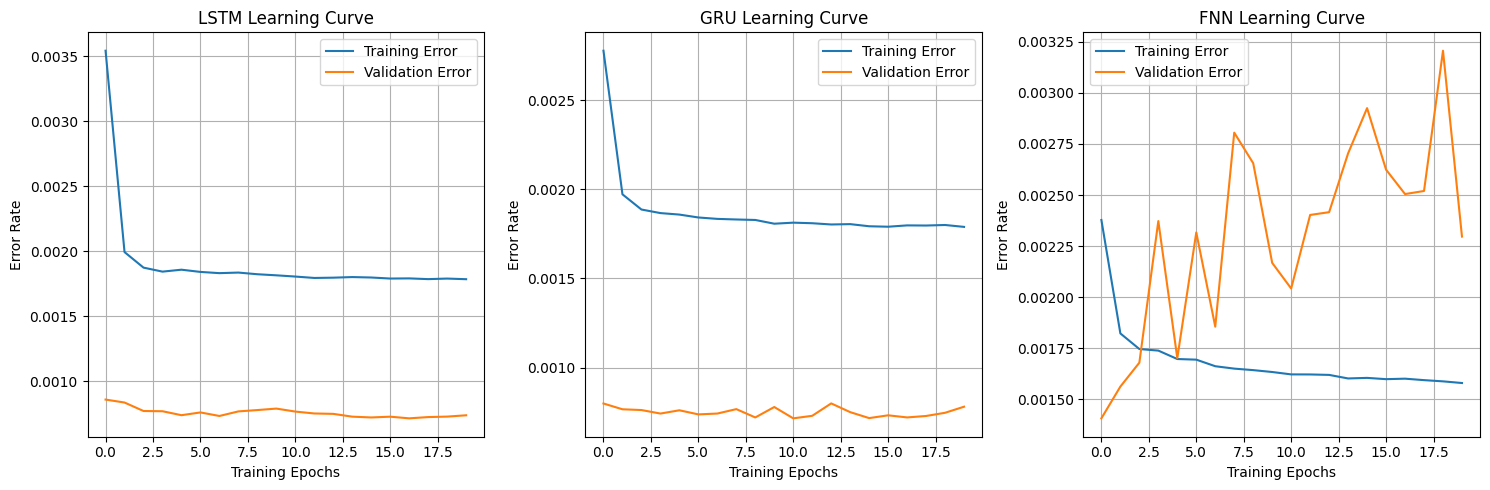

In [5]:
EPOCHS = 20
BATCH_SIZE = 32
histories = {}

print("Starting the training process...\n")

for name, model in models.items():
    print(f"Training {name} model...")
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2, # Holds back 20% to check for overfitting
        verbose=0 # Hides the line-by-line loading bar
    )
    histories[name] = history

    # Save the trained model to saved_models folder so the GUI can use it
    model_save_path = os.path.join(MODEL_DIR, f'{name.lower()}_model.keras')
    model.save(model_save_path)

print("\nAll models trained and saved. Generating performance graphs...")

# Draw the learning curves
plt.figure(figsize=(15, 5))
for i, (name, history) in enumerate(histories.items(), 1):
    plt.subplot(1, 3, i)
    plt.plot(history.history['loss'], label='Training Error')
    plt.plot(history.history['val_loss'], label='Validation Error')
    plt.title(f'{name} Learning Curve')
    plt.xlabel('Training Epochs')
    plt.ylabel('Error Rate')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## 5 - Final Comparison: Which model is best?

We now give the models a final exam using the 20% of data they have never seen before (the Testing set). We scale the predictions back up to real car numbers to understand exactly how wrong they were on average.

* **MAE (Mean Absolute Error):** On average, how many cars off was the prediction?
* **RMSE (Root Mean Squared Error):** This heavily penalizes the model if it gets a prediction completely wrong (like missing a massive traffic jam).
* **R² Score:** A score out of 1.0. The closer to 1.0, the better the model is at understanding the overall traffic trends.

In [6]:
evaluation_results = []

for name, model in models.items():
    # Ask the model to predict the testing sequence
    scaled_predictions = model.predict(X_test, verbose=0)

    # Convert the 0-1 scale back into real car counts
    y_pred_real = scaler.inverse_transform(scaled_predictions)
    y_test_real = scaler.inverse_transform(y_test)

    # Calculate the scores
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    r2 = r2_score(y_test_real, y_pred_real)

    evaluation_results.append({
        "Model": name,
        "Avg Error (Cars off)": round(mae, 2),
        "Major Error Penalty (RMSE)": round(rmse, 2),
        "Accuracy Score (R2)": round(r2, 4)
    })

# Show the final results table
results_df = pd.DataFrame(evaluation_results)
print("\n--- Final Model Performance Results ---")
display(results_df)

print("\nPhase 2 Complete. The best performing model will now be used by the Route Guidance System.")


--- Final Model Performance Results ---


,Model,Avg Error (Cars off),Major Error Penalty (RMSE),Accuracy Score (R2)
0,LSTM,25.16,34.6,0.9669
1,GRU,26.61,36.4,0.9634
2,FNN,43.66,52.9,0.9227



Phase 2 Complete. The best performing model will now be used by the Route Guidance System.
